In [68]:
import re
import requests
import string
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# BPE (Byte Pair Encoding)

In [69]:
# 1) LOAD AND CLEAN THE TEXT

book = requests.get("https://www.gutenberg.org/files/35/35-0.txt").text

# character strings to replace with spaces
strings2replace = ['\r\n\r\nâ\x80\x9c',
                   'â\x80\x9c',
                   'â\x80\x9d',
                   '\r\n',
                   'â\x80\x94',
                   'â\x80\x99',
                   'â\x80\x98','_', ]

# here we are cleaning the text, but normally this is done by the tokenizer
for str2match in strings2replace:
    book = re.sub(str2match, ' ', book) # using regex to replace all occurrences of the string with a space

# remove non-ASCII characters
book = re.sub(r'[^\x00-\x7F]+', ' ', book)

# remove numbers
#book = re.sub(r'\d+', ' ', book)

# make everything lowercase
#book = book.lower()

In [70]:
def get_stats(ids):
    """Counts the frequency of all adjacent pairs of integers."""
    counts = {}
    for pair in zip(ids, ids[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge(ids, pair, idx):
    """Replaces all occurrences of 'pair' with the new token 'idx'."""
    newids = []
    i = 0
    while i < len(ids):
        if i < len(ids) - 1 and ids[i] == pair[0] and ids[i+1] == pair[1]:
            newids.append(idx)
            i += 2
        else:
            newids.append(ids[i])
            i += 1
    return newids

In [71]:
# encode every character as its UTF-8 byte representation, resulting in a list of integers (0-255)
# it includes spaces and punctuation, which are important for tokenization, and it also allows us to see the effect of merges on the byte level
print(list("a b *".encode("utf-8"))) # example of how 5 characters are encoded as bytes

tokens = list(book.encode("utf-8")) 
vocab = {idx: bytes([idx]) for idx in set(tokens)}
print(f"Number of tokens (bytes) in the book: {len(tokens)}")
print(f"Unique tokens (bytes) in the book: {len(set(tokens))}")
print(vocab)

[97, 32, 98, 32, 42]
Number of tokens (bytes) in the book: 179777
Unique tokens (bytes) in the book: 66
{32: b' ', 33: b'!', 40: b'(', 41: b')', 42: b'*', 44: b',', 45: b'-', 46: b'.', 51: b'3', 53: b'5', 58: b':', 59: b';', 63: b'?', 65: b'A', 66: b'B', 67: b'C', 68: b'D', 69: b'E', 70: b'F', 71: b'G', 72: b'H', 73: b'I', 74: b'J', 75: b'K', 76: b'L', 77: b'M', 78: b'N', 79: b'O', 80: b'P', 81: b'Q', 82: b'R', 83: b'S', 84: b'T', 85: b'U', 86: b'V', 87: b'W', 88: b'X', 89: b'Y', 91: b'[', 93: b']', 97: b'a', 98: b'b', 99: b'c', 100: b'd', 101: b'e', 102: b'f', 103: b'g', 104: b'h', 105: b'i', 106: b'j', 107: b'k', 108: b'l', 109: b'm', 110: b'n', 111: b'o', 112: b'p', 113: b'q', 114: b'r', 115: b's', 116: b't', 117: b'u', 118: b'v', 119: b'w', 120: b'x', 121: b'y', 122: b'z'}


In [72]:
# understand how get_stats works
example_tokens = [1, 2, 3, 2, 3, 4]
print(f"Example IDs: {example_tokens}")
print(f"Adjacent pairs and their counts: {get_stats(example_tokens)}") 

# basically get_stats counts how many times each pair of adjacent tokens appears in the list of token IDs,
#  which is crucial for determining which pairs to merge in the BPE algorithm.

Example IDs: [1, 2, 3, 2, 3, 4]
Adjacent pairs and their counts: {(1, 2): 1, (2, 3): 2, (3, 2): 1, (3, 4): 1}


In [73]:
# understand how merge works
example_tokens = [1, 2, 3, 2, 3, 4, 3, 2]
pair_to_merge = (2, 3)
new_token_id = 5
print(f"Original IDs: {example_tokens}")
print(f"Merging pair: {pair_to_merge} into new token ID: {new_token_id}")
new_example_tokens = merge(example_tokens, pair_to_merge, new_token_id)
print(f"New IDs after merge: {new_example_tokens}")

# basically we are replacing every occurrence of the pair (2, 3) with the new token ID 5, which simulates how BPE merges pairs of tokens into a new token.

Original IDs: [1, 2, 3, 2, 3, 4, 3, 2]
Merging pair: (2, 3) into new token ID: 5
New IDs after merge: [1, 5, 5, 4, 3, 2]


In [74]:
# the length of the tokens or vocab should decrease as we merge pairs, while the number of unique tokens should increase as we create new tokens from merges
print(f"Len original tokens: {len(example_tokens)}")
print(f"Len new tokens: {len(new_example_tokens)}")
print(f"Len unique tokens before merge: {len(set(example_tokens))}")
print(f"Len unique tokens after merge: {len(set(new_example_tokens))}")

Len original tokens: 8
Len new tokens: 6
Len unique tokens before merge: 4
Len unique tokens after merge: 5


In [75]:
tokens = list(book.encode("utf-8")) 
vocab = {idx: bytes([idx]) for idx in set(tokens)}

ini_vocab_size = len(set(tokens)) # initial vocab size is the number of unique bytes
ini_token_count = len(tokens) # initial token count is the total number of bytes in the book
final_vocab_size = 300 # we want to expand the vocab to 300 tokens
num_merges = final_vocab_size - ini_vocab_size

for i in range(num_merges):
    stats = get_stats(tokens)
    if not stats: break
    
    # Find the most frequent pair
    top_pair = max(stats, key=stats.get)
    new_id = 256 + i # IDs 0-255 are reserved for raw bytes
    
    # Update the token list
    # we are basically replacing every occurrence of the most frequent pair with the new token ID, 
    # which simulates how BPE merges pairs of tokens into a new token.
    tokens = merge(tokens, top_pair, new_id) 

    # Update the vocab mapping
    # We concatenate the bytes of the two parts that made the new token
    vocab[new_id] = vocab[top_pair[0]] + vocab[top_pair[1]]
    
    # Debug: See what was just created
    new_token_str = vocab[new_id].decode('utf-8', errors='replace')
    print(f"Merge {i+1}: Created '{new_token_str}' (ID: {new_id})")

Merge 1: Created 'e ' (ID: 256)
Merge 2: Created ' t' (ID: 257)
Merge 3: Created ' th' (ID: 258)
Merge 4: Created ' a' (ID: 259)
Merge 5: Created 'in' (ID: 260)
Merge 6: Created 'd ' (ID: 261)
Merge 7: Created 't ' (ID: 262)
Merge 8: Created 'er' (ID: 263)
Merge 9: Created ' the ' (ID: 264)
Merge 10: Created 's ' (ID: 265)
Merge 11: Created '. ' (ID: 266)
Merge 12: Created 'en' (ID: 267)
Merge 13: Created 'y ' (ID: 268)
Merge 14: Created 'on' (ID: 269)
Merge 15: Created ' an' (ID: 270)
Merge 16: Created ', ' (ID: 271)
Merge 17: Created 'of' (ID: 272)
Merge 18: Created 'ou' (ID: 273)
Merge 19: Created 're' (ID: 274)
Merge 20: Created 'I ' (ID: 275)
Merge 21: Created 'ing' (ID: 276)
Merge 22: Created 'ha' (ID: 277)
Merge 23: Created 'or' (ID: 278)
Merge 24: Created 'it' (ID: 279)
Merge 25: Created 'st' (ID: 280)
Merge 26: Created 'wa' (ID: 281)
Merge 27: Created 'an' (ID: 282)
Merge 28: Created 'o ' (ID: 283)
Merge 29: Created 'ed' (ID: 284)
Merge 30: Created 'll' (ID: 285)
Merge 31: Cre

In [76]:
print(f"Initial vocab size: {ini_vocab_size}")
print(f"Initial token count: {ini_token_count}")

print(f"Final vocab size: {len(vocab)}")
print(f"Final token count: {len(tokens)}")

# as we can see, the vocab size has increased from the initial number of unique bytes to 300 tokens, while the total token count has decreased due to merges.

Initial vocab size: 66
Initial token count: 179777
Final vocab size: 300
Final token count: 83179


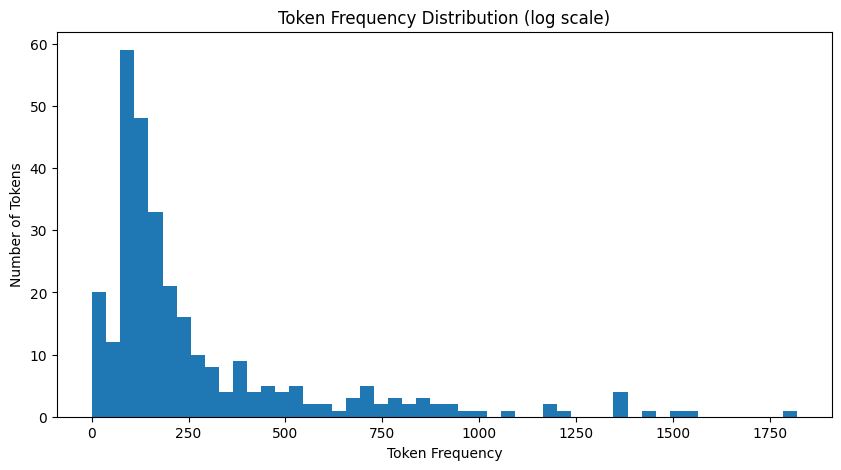

Top 5 most common tokens:
Token ID: 115, Token: 's', Count: 1820
Token ID: 116, Token: 't', Count: 1563
Token ID: 32, Token: ' ', Count: 1496
Token ID: 100, Token: 'd', Count: 1455
Token ID: 101, Token: 'e', Count: 1373


In [ ]:
# plot distribution of token frequencies
token_counts = Counter(tokens)
plt.figure(figsize=(10, 5))
plt.hist(token_counts.values(), bins=50, log=False)
plt.title("Token Frequency Distribution (log scale)")
plt.xlabel("Token Frequency")
plt.ylabel("Number of Tokens")
plt.show()

# print top 5 most common tokens
most_common_tokens = token_counts.most_common(5)
print("Top 5 most common tokens:")
for token_id, count in most_common_tokens:
    token_str = vocab[token_id].decode('utf-8', errors='replace')
    print(f"Token ID: {token_id}, Token: '{token_str}', Count: {count}")

# we can see that the tokens with more frequency are between 0 and 255, which are the original byte tokens, 
# while the new tokens created from merges have lower frequencies, which is expected since they represent more specific combinations of bytes.